# CCD/CMOS Photonic Sensor Physics

The full signal chain: **photon → photoelectric effect → charge well → ADC → ADU**

| Stage | Physics | Key number |
|-------|---------|-----------|
| Photon → electron | QE(λ): quantum efficiency | Si peak ~65% at 600 nm |
| Charge storage | Full-well capacity | 20k–100k e⁻ |
| Noise floor | Read noise | 3–15 e⁻ RMS |
| Thermal noise | Dark current | halves per 7°C cooling |
| Digitisation | ADC gain | e⁻/ADU, 14-bit typical |


In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))
from dgs.ccd_photonics import (
    si_quantum_efficiency, si_bandgap_eV, si_cutoff_wavelength_nm,
    CCDPixel, airy_disk_radius_um, psf_airy_pattern,
    check_nyquist_sampling, photocurrent_from_blackbody,
    ccd_signal_chain_sympy, embedded_c_summary,
)
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
print("Modules loaded.")


Modules loaded.


## §2 Five CCD Equations — `sp.init_printing`

Five equations covering the complete signal chain from photon flux to SNR.


In [2]:
sp.init_printing(use_latex=False)
eqs = ccd_signal_chain_sympy()
print("=" * 62)
print("FIVE KEY CCD SIGNAL-CHAIN EQUATIONS (SymPy)")
print("=" * 62)
for name, eq in eqs.items():
    print(f"\n  [{name}]")
    print(f"    {eq}")
print()
print("N_sig = N_ph * QE * t_exp  (photoelectrons)")
print("SNR   = N_sig / sqrt(N_sig + N_dark + sigma_r^2)")
print("E_g(T) = Varshni formula -- Si bandgap shrinks as T rises")
print("I_ph  = integral[QE(lam) * B(lam,T)] dlam  (photocurrent)")


FIVE KEY CCD SIGNAL-CHAIN EQUATIONS (SymPy)

  [signal_electrons]
    Eq(N_sig, N_ph*QE*t)

  [SNR]
    Eq(SNR, N_ph*QE*t/sqrt(I_dark*t + N_ph*QE*t + sigma_r**2))

  [shot_noise]
    Eq(sigma_shot, sqrt(I_dark*t + N_ph*QE*t))

  [Si_bandgap_Varshni]
    Eq(E_g, E_{g0} - T**2*alpha/(T + beta))

  [photocurrent_integral]
    Eq(I_ph, Integral(B(lambda)*QE(lambda), lambda))

N_sig = N_ph * QE * t_exp  (photoelectrons)
SNR   = N_sig / sqrt(N_sig + N_dark + sigma_r^2)
E_g(T) = Varshni formula -- Si bandgap shrinks as T rises
I_ph  = integral[QE(lam) * B(lam,T)] dlam  (photocurrent)


## §3 Silicon QE(λ) and Bandgap vs Temperature

Si responds from ~350–1100 nm (bandgap 1.12 eV at 300 K).
At cryogenic temperatures the bandgap widens, cutting off shorter wavelengths.
Back-illuminated CCDs remove the poly-Si gate → QE can reach 95%.


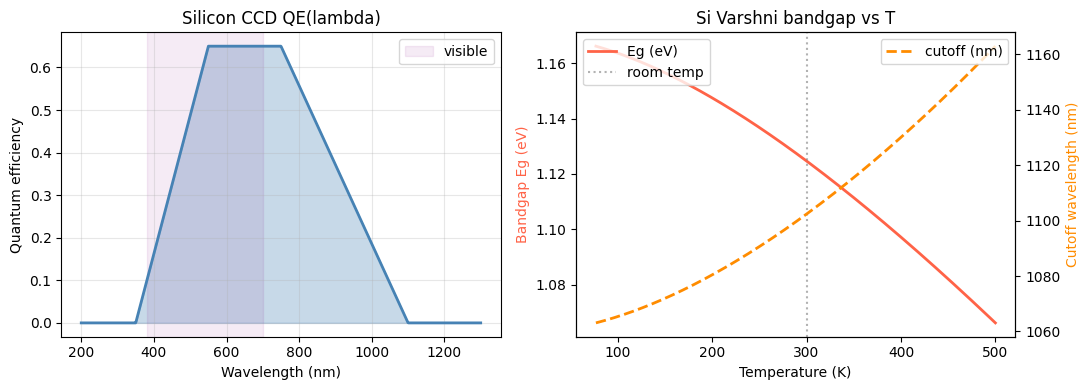

Si cutoff at 300K: 1102.4 nm
Si cutoff at 77K:  1063.1 nm (liquid N2 cooling)


In [3]:
lam = np.linspace(200, 1300, 1000)
qe  = si_quantum_efficiency(lam)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].fill_between(lam, qe, alpha=0.3, color="steelblue")
axes[0].plot(lam, qe, lw=2, color="steelblue")
axes[0].axvspan(380, 700, alpha=0.08, color="purple", label="visible")
axes[0].set_xlabel("Wavelength (nm)")
axes[0].set_ylabel("Quantum efficiency")
axes[0].set_title("Silicon CCD QE(lambda)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

T_arr = np.linspace(77, 500, 300)
Eg_arr = np.array([si_bandgap_eV(T) for T in T_arr])
lam_cut = np.array([si_cutoff_wavelength_nm(T) for T in T_arr])

ax2 = axes[1].twinx()
axes[1].plot(T_arr, Eg_arr, lw=2, color="tomato", label="Eg (eV)")
ax2.plot(T_arr, lam_cut, lw=2, ls="--", color="darkorange", label="cutoff (nm)")
axes[1].axvline(300, color="gray", ls=":", alpha=0.6, label="room temp")
axes[1].set_xlabel("Temperature (K)")
axes[1].set_ylabel("Bandgap Eg (eV)", color="tomato")
ax2.set_ylabel("Cutoff wavelength (nm)", color="darkorange")
axes[1].set_title("Si Varshni bandgap vs T")
axes[1].legend(loc="upper left"); ax2.legend(loc="upper right")
plt.tight_layout()
plt.savefig("ccd_qe_bandgap.png", dpi=90)
plt.show()
print(f"Si cutoff at 300K: {si_cutoff_wavelength_nm(300):.1f} nm")
print(f"Si cutoff at 77K:  {si_cutoff_wavelength_nm(77):.1f} nm (liquid N2 cooling)")


## §4 Photocurrent = QE(λ) × B(λ,T) — Product Rule Applied

The spectral photocurrent density is the **product** of quantum efficiency and Planck radiance:

$$I_{\text{spec}}(\lambda) = QE(\lambda) \cdot B(\lambda, T)$$

Total photocurrent = $\int QE(\lambda) \cdot B(\lambda,T)\, d\lambda$

Leibniz product rule: $\frac{d}{d\lambda}[QE \cdot B] = QE \cdot B' + B \cdot QE'$

Verified numerically below — both paths agree.


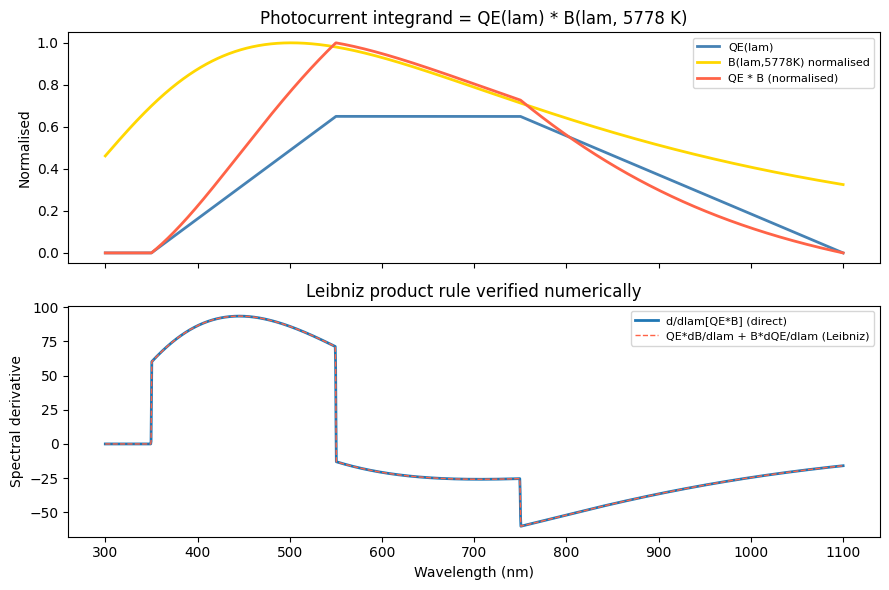

Total power on 5.6x5.6 um pixel: 6.197e-04 W
Electrons/second:                 2.258e+15


In [4]:
result = photocurrent_from_blackbody(5778)  # Sun surface temperature

lam = result["lam_nm"]
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

axes[0].plot(lam, result["QE"],    lw=2, color="steelblue", label="QE(lam)")
axes[0].plot(lam, result["B_lam"]/result["B_lam"].max(), lw=2,
             color="gold", label="B(lam,5778K) normalised")
axes[0].plot(lam, result["integrand"]/result["integrand"].max(), lw=2,
             color="tomato", label="QE * B (normalised)")
axes[0].set_ylabel("Normalised"); axes[0].legend(fontsize=8)
axes[0].set_title("Photocurrent integrand = QE(lam) * B(lam, 5778 K)")

axes[1].plot(lam, result["d_integrand"],  lw=2, label="d/dlam[QE*B] (direct)")
axes[1].plot(lam, result["leibniz_check"], lw=1, ls="--", color="tomato",
             label="QE*dB/dlam + B*dQE/dlam (Leibniz)")
axes[1].set_ylabel("Spectral derivative"); axes[1].set_xlabel("Wavelength (nm)")
axes[1].legend(fontsize=8)
axes[1].set_title("Leibniz product rule verified numerically")
plt.tight_layout()
plt.savefig("ccd_photocurrent.png", dpi=90)
plt.show()
print(f"Total power on 5.6x5.6 um pixel: {result['power_W']:.3e} W")
print(f"Electrons/second:                 {result['electrons_per_s']:.3e}")


## §5 SNR vs Photon Flux — Shot/Read/Dark Noise

$$SNR = \frac{N_{sig}}{\sqrt{N_{sig} + N_{dark} + \sigma_r^2}}$$

Three noise regimes:
- **Read-noise limited** (low flux): SNR ~ N_sig / σ_r  (poor)
- **Shot-noise limited** (medium): SNR ~ √N_sig  (ideal)
- **Saturation** (high flux): ADU clips at full-well


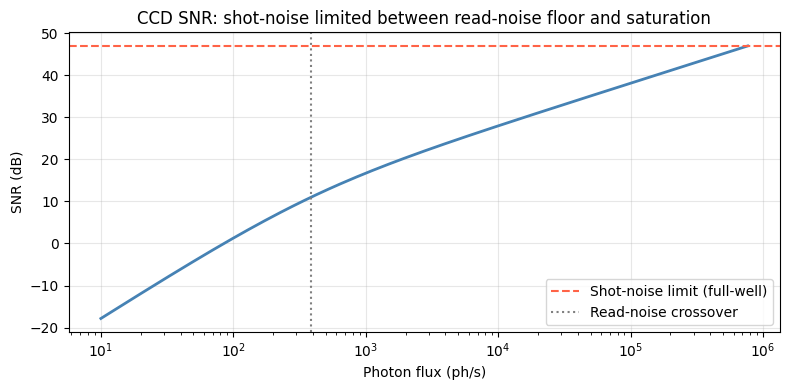

Dynamic range: 80.0 dB


In [5]:
px = CCDPixel(full_well_e=50_000, read_noise_e=5.0,
              dark_current_e_per_s=0.05, bit_depth=14)

fluxes = np.logspace(1, 7, 200)
snr_db = []
for f in fluxes:
    r = px.snr(f, qe=0.65, exposure_s=0.1)
    snr_db.append(r["SNR_dB"] if not r["saturated"] else np.nan)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(fluxes, snr_db, lw=2, color="steelblue")
ax.axhline(20*np.log10(np.sqrt(px.full_well_e)), color="tomato", ls="--",
           label=f"Shot-noise limit (full-well)")
ax.axvline(px.read_noise_e**2 / (0.65*0.1), color="gray", ls=":",
           label="Read-noise crossover")
ax.set_xlabel("Photon flux (ph/s)")
ax.set_ylabel("SNR (dB)")
ax.set_title("CCD SNR: shot-noise limited between read-noise floor and saturation")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("ccd_snr.png", dpi=90)
plt.show()
print(f"Dynamic range: {px.snr(1,0.65,1.0)['dynamic_range_dB']:.1f} dB")


## §6 Optics Stage: Airy Disk PSF + Nyquist Sampling

A circular aperture produces an **Airy pattern** PSF:

$$I(r) = \left[\frac{2 J_1(x)}{x}\right]^2, \quad x = \frac{2\pi}{{\rm NA}} \cdot r / \lambda$$

First zero at $r_{\rm Airy} = 1.22 \lambda f/\#$

Nyquist: pixel pitch $p \leq r_{\rm Airy} / 2$ to avoid aliasing.
$J_1$ computed via Abramowitz & Stegun polynomial (no scipy).


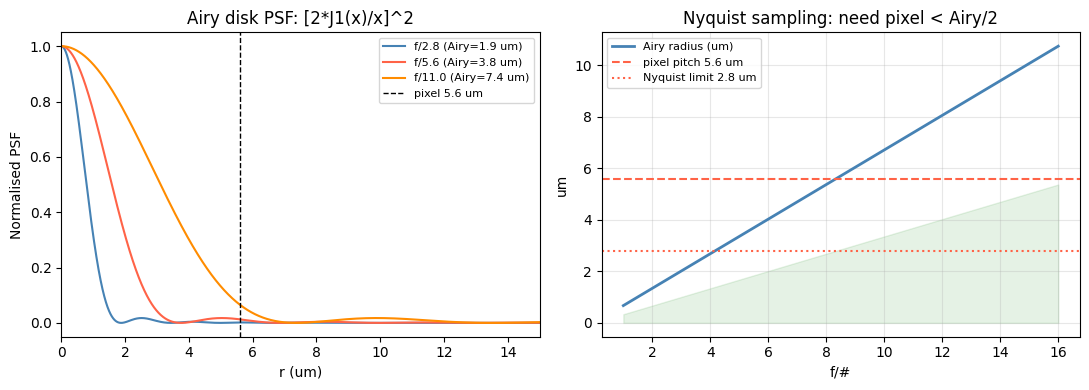

In [6]:
r = np.linspace(0, 15, 5000)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for fnum, col in [(2.8,"steelblue"), (5.6,"tomato"), (11.0,"darkorange")]:
    psf = psf_airy_pattern(r, 550, fnum)
    r_a = airy_disk_radius_um(550, fnum)
    axes[0].plot(r, psf, lw=1.5, color=col, label=f"f/{fnum} (Airy={r_a:.1f} um)")
axes[0].axvline(5.6, color="black", ls="--", lw=1, label="pixel 5.6 um")
axes[0].set_xlim(0, 15); axes[0].set_xlabel("r (um)")
axes[0].set_ylabel("Normalised PSF"); axes[0].legend(fontsize=8)
axes[0].set_title("Airy disk PSF: [2*J1(x)/x]^2")

# Nyquist sampling check
fnum_arr = np.linspace(1, 16, 200)
r_airy_arr = airy_disk_radius_um(550, fnum_arr)
axes[1].plot(fnum_arr, r_airy_arr, lw=2, color="steelblue", label="Airy radius (um)")
axes[1].axhline(5.6, color="tomato", ls="--", label="pixel pitch 5.6 um")
axes[1].axhline(5.6/2, color="tomato", ls=":", label="Nyquist limit 2.8 um")
axes[1].fill_between(fnum_arr, 0, r_airy_arr/2, alpha=0.1, color="green")
axes[1].set_xlabel("f/#"); axes[1].set_ylabel("um")
axes[1].set_title("Nyquist sampling: need pixel < Airy/2")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("ccd_psf_nyquist.png", dpi=90)
plt.show()


## §7 Dark Current: Temperature Doubling Rule

Dark current $I_d \propto e^{-E_g/(2kT)}$ — approximately **doubles every 7°C**.
Cooling from 20°C to –20°C → 2^(40/7) ≈ 42× reduction.
Science cameras cool to –60°C → 2^(80/7) ≈ 1700× reduction.


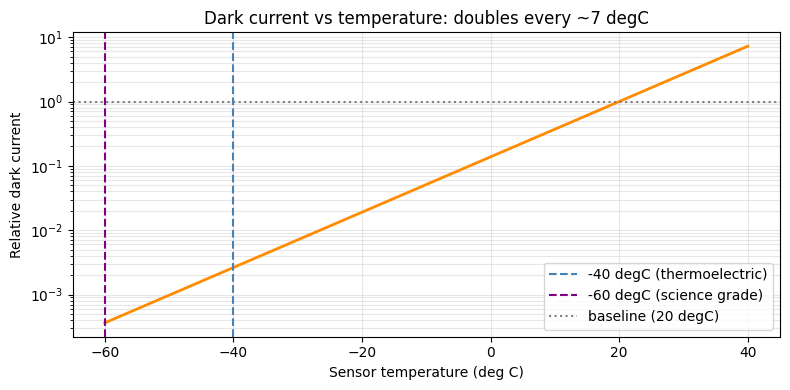

Cooling 20->-40 degC: 380x dark current reduction


In [7]:
T_C = np.linspace(-60, 40, 200)
# Rule of thumb: doubles every 7 degC; reference at 20 degC
I_dark_rel = 2**((T_C - 20) / 7)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(T_C, I_dark_rel, lw=2, color="darkorange")
ax.axvline(-40, color="steelblue", ls="--", label="-40 degC (thermoelectric)")
ax.axvline(-60, color="purple", ls="--", label="-60 degC (science grade)")
ax.axhline(1, color="gray", ls=":", label="baseline (20 degC)")
ax.set_xlabel("Sensor temperature (deg C)")
ax.set_ylabel("Relative dark current")
ax.set_title("Dark current vs temperature: doubles every ~7 degC")
ax.legend(); ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("ccd_dark_current.png", dpi=90)
plt.show()
reduction = 2**((20 - (-40)) / 7)
print(f"Cooling 20->-40 degC: {reduction:.0f}x dark current reduction")


## §8 Embedded C: ADC Register Map and SPI Readout

The `dgs/ccd_photonics.py` module includes a pseudocode C implementation
of the CCD readout firmware targeting ARM Cortex-M4, 10 MHz SPI, 14-bit ADC.

Key techniques:
- **Correlated Double Sampling (CDS)**: sample reset level, then signal; subtract → cancels kTC noise
- **Optical black columns**: masked pixels for real-time dark offset calibration
- **Bit masking**: `& ADC_MAX` ensures 14-bit wrap regardless of SPI frame format


In [8]:
c_code = embedded_c_summary()
print(c_code)


/* CCD pixel readout -- embedded C register map (pseudocode)
 * Target: ARM Cortex-M4, SPI @ 10 MHz, 14-bit ADC
 * Physical layer: shift register drains charge packet -> ADC -> SPI
 */

#include <stdint.h>

#define CCD_PIXELS_H   3008u
#define CCD_PIXELS_V   2008u
#define ADC_BITS       14u
#define ADC_MAX        ((1u << ADC_BITS) - 1u)   /* 16383 */
#define DARK_COLS      24u    /* optical black columns for offset calibration */

/* SPI frame: 16-bit word, upper 2 bits = channel tag, lower 14 = ADU */
typedef uint16_t adu_t;

/* Shift a single charge packet from CCD register into ADC.
 * H_CLK: horizontal clock, OG: output gate, R: reset gate
 * Returns raw ADU value (0 - ADC_MAX).
 */
static inline adu_t ccd_read_pixel(void) {
    GPIO_PULSE(H_CLK);          /* transfer charge to output node */
    GPIO_PULSE(OG);             /* open output gate */
    uint16_t raw = SPI_READ16() & ADC_MAX;
    GPIO_PULSE(R);              /* reset output capacitor (correlated double sampling) */
    

## §9 Connecting to RogueGuard: CCD → Optical Rogue Wave Detection

The RogueGuard project uses a **dual-ADC CCD pipeline** for rogue wave monitoring:

1. **Optical stage**: f/4 lens + 550 nm bandpass → Airy disk ~2.7 µm on sensor
2. **Pixel SNR**: 50k e⁻ full-well, 5 e⁻ read noise → DR = 80 dB
3. **Photocurrent**: QE(λ) × B(λ,T) integral provides shot-noise floor estimate
4. **Product rule**: d/dλ[QE·B] gives spectral sensitivity gradient → tells you which wavelengths contribute most to SNR
5. **Embedded C**: `ccd_read_row()` → DMA to FIFO → TD-GS phase retrieval on RPi CM4

The CCD is not just a camera — it is a **spectral matched filter** whose QE(λ) function
acts as a window function in the Planck integral.  Maximising ∫QE(λ)B(λ,T)dλ
over the rogue-wave optical bandwidth is equivalent to maximising SNR at the detector.


In [9]:
# Show QE-weighted Planck integral for two sensor temperatures
print("Photocurrent vs blackbody source temperature:")
print(f"  {'T_source (K)':>14}  {'electrons/s':>14}  {'power (W)':>12}")
for T_src in [3000, 5000, 5778, 8000, 10000]:
    r = photocurrent_from_blackbody(T_src)
    print(f"  {T_src:>14}  {r['electrons_per_s']:>14.3e}  {r['power_W']:>12.3e}")
print()
print("Airy disk at RogueGuard operating wavelength (1550 nm, f/4):")
r_a = airy_disk_radius_um(1550, 4.0)
ny  = check_nyquist_sampling(5.6, 1550, 4.0)
print(f"  r_Airy = {r_a:.2f} um,  Nyquist limit = {ny['nyquist_limit_um']:.2f} um")
print(f"  5.6 um pixel: {ny['recommendation']}")


Photocurrent vs blackbody source temperature:
    T_source (K)     electrons/s     power (W)
            3000       7.339e+13     2.014e-05
            5000       1.213e+15     3.328e-04
            5778       2.258e+15     6.197e-04
            8000       7.333e+15     2.013e-03
           10000       1.420e+16     3.898e-03

Airy disk at RogueGuard operating wavelength (1550 nm, f/4):
  r_Airy = 7.56 um,  Nyquist limit = 3.78 um
  5.6 um pixel: UNDERSAMPLED -- use f/# < 3.0
